<a href="https://colab.research.google.com/github/sxryadipta/hls-resource-estimation/blob/main/HLSDataset_CaseStudy2_Colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# HLSDataset — Case Study 2: Resource Estimation (XGB + Lasso)
### Reproducing Table VI from Wei et al., arXiv:2302.10977

**Paper:** *HLSDataset: Open-Source Dataset for ML-Assisted FPGA Design using High Level Synthesis*  
**Real dataset repo:** https://github.com/UT-LCA/ML4Accel-Dataset/tree/main/fpga_ml_dataset

---
### What this notebook does
1. Installs dependencies
2. Generates **synthetic data** that mirrors the real HLSDataset CSV schema (8 735 samples, ZU9EG FPGA)  
   *(swap in the real CSVs in Section 3 to get publication numbers)*
3. Trains **XGBoost** and **Lasso** (single-task, 10-fold CV, 20% held-out test)
4. Prints **Table VI** and plots all figures

### Paper methodology recap
| Item | Value |
|---|---|
| Dataset | Machsuite + Polybench subsets (~8 735 samples) |
| FPGA | ZU9EG |
| Test split | Random 20% |
| CV | 10-fold (75 % train / 25 % val within fold) |
| Metric | MAPE — Mean Absolute Percentage Error |
| Targets | #LUT, #FF, #DSP, #BRAM post-implementation |

### Expected Table VI
| Model | LUT | FF | DSP | BRAM |
|---|---|---|---|---|
| HLS Estimate | 63.2 % | 34.1 % | 0.0 % | 1.8 % |
| **XGB** | **3.2 %** | **2.3 %** | NA | **0.1 %** |
| Lasso | 13.2 % | 15.4 % | NA | NA |

---
## Cell 1 — Install dependencies

In [1]:
!pip install xgboost scikit-learn pandas numpy matplotlib seaborn -q
print('✓ All packages ready')

✓ All packages ready


---
## Cell 2 — Imports

In [2]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from pathlib import Path

from sklearn.linear_model import LassoCV
from sklearn.model_selection import KFold, train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
import xgboost as xgb

SEED = 42
np.random.seed(SEED)
print('✓ Imports done')

✓ Imports done


---
## Cell 3 — Generate synthetic data (mirrors real HLSDataset schema)

> **To use the REAL dataset instead:**  
> 1. Clone https://github.com/UT-LCA/ML4Accel-Dataset  
> 2. Concatenate the per-benchmark `post_hls_info.csv` files into one DataFrame → assign to `hls_df`  
> 3. Do the same for `post_impl_info.csv` → assign to `impl_df`  
> 4. Skip this cell and jump to Cell 4

The synthetic data is calibrated so the HLS baseline errors match the paper:
- LUT ≈ 63 %  (HLS tool overestimates by ~1.63×)
- FF  ≈ 34 %  (HLS tool overestimates by ~1.34×)
- DSP ≈ 0 %   (accurate)
- BRAM ≈ 2 %  (accurate)

In [3]:
# ── Benchmark registry: (sample_weight, bram_scale, dsp_scale, ff_scale, lut_scale) ──
BENCHMARKS = {
    # Polybench
    'atax'         : (0.07, 0.05, 0.05, 0.50, 0.80),
    'bicg'         : (0.07, 0.05, 0.05, 0.40, 0.70),
    'gemm'         : (0.10, 0.20, 0.30, 1.00, 1.50),
    'gesummv'      : (0.07, 0.05, 0.10, 0.50, 0.90),
    'k2mm'         : (0.08, 0.15, 0.25, 0.80, 1.20),
    'k3mm'         : (0.08, 0.20, 0.30, 0.90, 1.40),
    'mvt'          : (0.07, 0.05, 0.05, 0.40, 0.70),
    'syrk'         : (0.08, 0.10, 0.15, 0.60, 1.00),
    'syr2k'        : (0.08, 0.15, 0.20, 0.70, 1.10),
    # Machsuite
    'bfs_bulk'     : (0.04, 0.30, 0.02, 0.60, 0.90),
    'bfs_queue'    : (0.04, 0.25, 0.02, 0.50, 0.80),
    'fft_transpose': (0.04, 0.10, 0.20, 0.80, 1.00),
    'sort_merge'   : (0.04, 0.10, 0.02, 0.50, 0.80),
    'sort_radix'   : (0.04, 0.10, 0.02, 0.50, 0.80),
    'stencil2d'    : (0.04, 0.10, 0.05, 0.60, 0.90),
    'stencil3d'    : (0.04, 0.15, 0.08, 0.70, 1.00),
    'backprop'     : (0.03, 0.25, 0.40, 1.50, 2.00),
}

FPGA = dict(bram=912, dsp=2520, ff=548160, lut=274080)  # ZU9EG capacity
N    = 8735
rng  = np.random.default_rng(SEED)

bench_names = list(BENCHMARKS.keys())
weights     = np.array([v[0] for v in BENCHMARKS.values()])
weights    /= weights.sum()
bench_idx   = rng.choice(len(bench_names), size=N, p=weights)

# ── Build post_hls_info rows ──────────────────────────────────────────────────
hls_rows = []
for i in bench_idx:
    name = bench_names[i]
    _, bs, ds, fs, ls = BENCHMARKS[name]

    unroll    = int(rng.choice([1, 2, 4, 8, 16]))
    pipeline  = int(rng.choice([0, 1]))
    ap_factor = int(rng.choice([1, 2, 4, 8, 16, 32]))
    scale     = (1 + 0.3*np.log2(max(unroll,1))
                   + 0.2*pipeline
                   + 0.15*np.log2(max(ap_factor,1)))

    def hls_est(base, cap, noise=0.12):
        return int(np.clip(rng.normal(base*cap*scale, base*cap*noise), 0, cap))

    n_add = int(rng.integers(1, 30));  n_mul = int(rng.integers(0, 20))
    n_sub = int(rng.integers(0, 10));  n_or  = int(rng.integers(0, 8))
    n_shl = int(rng.integers(0, 8));   n_shr = int(rng.integers(0, 8))
    n_and = int(rng.integers(0, 8));   n_cmp = int(rng.integers(0, 12))

    hls_rows.append(dict(
        benchmark=name,
        unroll_factor=unroll, pipeline=pipeline, array_partition_factor=ap_factor,
        bram_hls=hls_est(bs,FPGA['bram']), bram_avail=FPGA['bram'],
        dsp_hls =hls_est(ds,FPGA['dsp']),  dsp_avail =FPGA['dsp'],
        ff_hls  =hls_est(fs,FPGA['ff']),   ff_avail  =FPGA['ff'],
        lut_hls =hls_est(ls,FPGA['lut']),  lut_avail =FPGA['lut'],
        target_clock_period=10.0,
        estimated_clock_period=round(rng.uniform(7.0,9.5),3),
        clock_uncertainty=round(rng.uniform(0.1,0.5),3),
        n_add=n_add, n_mul=n_mul, n_sub=n_sub,
        n_or=n_or,   n_shl=n_shl, n_shr=n_shr, n_and=n_and, n_cmp=n_cmp,
        lut_add=n_add*2, lut_mul=n_mul*15, dsp_mul=n_mul//2,
        n_input_ports=int(rng.integers(1,8)),
        n_output_ports=int(rng.integers(1,4)),
        port_width_bits=int(rng.choice([8,16,32,64])),
        n_registers=int(rng.integers(10,500)),
        n_mux=int(rng.integers(1,50)),
        n_memory_elements=int(rng.integers(0,20)),
    ))

hls_df = pd.DataFrame(hls_rows)

# ── Build post_impl_info rows  (HLS overestimates LUT/FF; DSP/BRAM accurate) ─
impl_rows = []
for _, r in hls_df.iterrows():
    impl_rows.append(dict(
        bram_impl = max(0, int(r.bram_hls * rng.normal(1.00, 0.018))),
        dsp_impl  = max(0, int(r.dsp_hls  * rng.normal(1.00, 0.008))),
        ff_impl   = max(0, int(r.ff_hls   / rng.normal(1.34, 0.08))),   # ~34% overestimate
        lut_impl  = max(0, int(r.lut_hls  / rng.normal(1.63, 0.12))),   # ~63% overestimate
        achieved_clock_period = round(rng.normal(9.2, 0.3), 3),
    ))

impl_df = pd.DataFrame(impl_rows)

print(f'✓ Generated {N} samples')
print(f'  post_hls_info  : {hls_df.shape}')
print(f'  post_impl_info : {impl_df.shape}')
hls_df.head(3)

✓ Generated 8735 samples
  post_hls_info  : (8735, 32)
  post_impl_info : (8735, 5)


,benchmark,unroll_factor,pipeline,array_partition_factor,bram_hls,bram_avail,dsp_hls,dsp_avail,ff_hls,ff_avail,...,n_cmp,lut_add,lut_mul,dsp_mul,n_input_ports,n_output_ports,port_width_bits,n_registers,n_mux,n_memory_elements
0,fft_transpose,1,0,16,139,912,826,2520,548160,548160,...,4,32,225,7,1,3,64,11,39,15
1,k3mm,4,1,16,477,912,1833,2520,548160,548160,...,1,28,120,4,1,1,64,142,8,13
2,sort_radix,16,0,16,242,912,135,2520,548160,548160,...,7,26,30,1,1,2,16,84,40,6


---
## Cell 4 — Merge & define features / targets

In [4]:
df = pd.concat([hls_df, impl_df], axis=1)
print(f'Combined dataframe: {df.shape}')

# ── Feature groups (Table III / Table IV of paper) ────────────────────────────
HLS_ESTIMATES  = ['bram_hls','dsp_hls','ff_hls','lut_hls']
CLOCK_FEATS    = ['estimated_clock_period','clock_uncertainty','target_clock_period']
LOGIC_OPS      = ['n_or','n_shl','n_shr','n_and','n_cmp']
ARITH_OPS      = ['n_add','n_mul','n_sub','lut_add','lut_mul','dsp_mul']
MEMORY_MUX     = ['n_registers','n_mux','n_memory_elements']
PORT_FEATS     = ['n_input_ports','n_output_ports','port_width_bits']
PRAGMA_FEATS   = ['unroll_factor','pipeline','array_partition_factor']

ALL_FEATURES = (HLS_ESTIMATES + CLOCK_FEATS + LOGIC_OPS +
                ARITH_OPS + MEMORY_MUX + PORT_FEATS + PRAGMA_FEATS)

# ── Targets: post-implementation ground truth ─────────────────────────────────
TARGETS      = {'lut':'lut_impl',  'ff':'ff_impl',  'dsp':'dsp_impl',  'bram':'bram_impl'}
HLS_BASELINE = {'lut':'lut_hls',   'ff':'ff_hls',   'dsp':'dsp_hls',   'bram':'bram_hls'}

feature_cols = [c for c in ALL_FEATURES if c in df.columns]
X = df[feature_cols].fillna(0)
print(f'Features: {len(feature_cols)}')
print(f'Benchmarks: {sorted(df.benchmark.unique())}')

Combined dataframe: (8735, 37)
Features: 27
Benchmarks: ['atax', 'backprop', 'bfs_bulk', 'bfs_queue', 'bicg', 'fft_transpose', 'gemm', 'gesummv', 'k2mm', 'k3mm', 'mvt', 'sort_merge', 'sort_radix', 'stencil2d', 'stencil3d', 'syr2k', 'syrk']


---
## Cell 5 — Train / test split
Paper: *"randomly select 20 % of 8 735 samples as the testing set"*

In [5]:
tr_idx, te_idx = train_test_split(np.arange(len(df)), test_size=0.20, random_state=SEED)

X_tv = X.iloc[tr_idx].reset_index(drop=True)   # train+val
X_te = X.iloc[te_idx].reset_index(drop=True)   # held-out test

print(f'Train+val : {len(tr_idx):,}')
print(f'Test      : {len(te_idx):,}')

Train+val : 6,988
Test      : 1,747


---
## Cell 6 — Helper functions

In [6]:
def mape(y_true, y_pred):
    """Mean Absolute Percentage Error (%), guarded against divide-by-zero."""
    y_true, y_pred = np.array(y_true, float), np.array(y_pred, float)
    mask = y_true != 0
    return 100.0 * np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) if mask.sum() else np.nan


def make_xgb():
    return xgb.XGBRegressor(
        n_estimators=400, max_depth=6, learning_rate=0.05,
        subsample=0.8, colsample_bytree=0.8,
        min_child_weight=3, reg_alpha=0.1, reg_lambda=1.0,
        random_state=SEED, verbosity=0,
    )


def make_lasso():
    return Pipeline([
        ('sc', StandardScaler()),
        ('la', LassoCV(cv=5, max_iter=10000, random_state=SEED)),
    ])


def run_10fold_cv(X_tv, y_tv, model_fn):
    """10-fold CV — returns (y_true_all, y_pred_all) across folds."""
    kf = KFold(n_splits=10, shuffle=True, random_state=SEED)
    yt_all, yp_all = [], []
    for tr, va in kf.split(X_tv):
        m = model_fn()
        m.fit(X_tv.iloc[tr], y_tv.iloc[tr])
        pred = np.clip(m.predict(X_tv.iloc[va]), 0, None)
        yt_all.extend(y_tv.iloc[va].tolist())
        yp_all.extend(pred.tolist())
    return np.array(yt_all), np.array(yp_all)


def train_final(X_tv, y_tv, model_fn):
    m = model_fn()
    m.fit(X_tv, y_tv)
    return m

print('✓ Helpers defined')

✓ Helpers defined


---
## Cell 7 — HLS tool baseline (Table VI, row 1)

In [7]:
hls_errors = {}
print('HLS Tool Baseline MAPE (%) — entire dataset:')
print('-' * 35)
for res, impl_col in TARGETS.items():
    err = mape(df[impl_col], df[HLS_BASELINE[res]])
    hls_errors[res] = round(err, 1)
    print(f'  {res.upper():5s}: {err:.1f} %')
print()
print('Paper values: LUT=63.2%  FF=34.1%  DSP=0.0%  BRAM=1.8%')

HLS Tool Baseline MAPE (%) — entire dataset:
-----------------------------------
  LUT  : 63.2 %
  FF   : 34.0 %
  DSP  : 0.7 %
  BRAM : 1.5 %

Paper values: LUT=63.2%  FF=34.1%  DSP=0.0%  BRAM=1.8%


---
## Cell 8 — Train XGBoost (10-fold CV + held-out test)

In [8]:
xgb_cv_errors   = {}
xgb_test_errors = {}
xgb_models      = {}
xgb_test_preds  = {}

print('XGBoost — 10-fold CV  (this takes ~1-2 min on Colab free tier)')
print('-' * 55)

for res, impl_col in TARGETS.items():
    y     = df[impl_col]
    y_tv  = y.iloc[tr_idx].reset_index(drop=True)
    y_te  = y.iloc[te_idx].reset_index(drop=True)

    # 10-fold CV (primary metric reported in paper)
    yt_cv, yp_cv = run_10fold_cv(X_tv, y_tv, make_xgb)
    cv_err = round(mape(yt_cv, yp_cv), 1)

    # Final model on full train+val → evaluate on held-out test
    m = train_final(X_tv, y_tv, make_xgb)
    yp_te = np.clip(m.predict(X_te), 0, None)
    te_err = round(mape(y_te, yp_te), 1)

    xgb_cv_errors[res]   = cv_err
    xgb_test_errors[res] = te_err
    xgb_models[res]      = m
    xgb_test_preds[res]  = (y_te.values, yp_te)

    print(f'  {res.upper():5s}  CV MAPE = {cv_err:.1f}%   held-out test = {te_err:.1f}%')

XGBoost — 10-fold CV  (this takes ~1-2 min on Colab free tier)
-------------------------------------------------------
  LUT    CV MAPE = 6.2%   held-out test = 6.3%
  FF     CV MAPE = 4.9%   held-out test = 5.2%
  DSP    CV MAPE = 2.3%   held-out test = 2.2%
  BRAM   CV MAPE = 1.7%   held-out test = 1.7%


---
## Cell 9 — Train Lasso (10-fold CV + held-out test)

In [9]:
lasso_cv_errors   = {}
lasso_test_errors = {}
lasso_models      = {}
lasso_test_preds  = {}

print('Lasso — 10-fold CV')
print('-' * 55)

for res, impl_col in TARGETS.items():
    y     = df[impl_col]
    y_tv  = y.iloc[tr_idx].reset_index(drop=True)
    y_te  = y.iloc[te_idx].reset_index(drop=True)

    yt_cv, yp_cv = run_10fold_cv(X_tv, y_tv, make_lasso)
    cv_err = round(mape(yt_cv, yp_cv), 1)

    m = train_final(X_tv, y_tv, make_lasso)
    yp_te = np.clip(m.predict(X_te), 0, None)
    te_err = round(mape(y_te, yp_te), 1)

    lasso_cv_errors[res]   = cv_err
    lasso_test_errors[res] = te_err
    lasso_models[res]      = m
    lasso_test_preds[res]  = (y_te.values, yp_te)

    print(f'  {res.upper():5s}  CV MAPE = {cv_err:.1f}%   held-out test = {te_err:.1f}%')

Lasso — 10-fold CV
-------------------------------------------------------
  LUT    CV MAPE = 6.0%   held-out test = 6.1%
  FF     CV MAPE = 4.8%   held-out test = 5.0%
  DSP    CV MAPE = 0.7%   held-out test = 0.7%
  BRAM   CV MAPE = 1.5%   held-out test = 1.5%


---
## Cell 10 — Print Table VI

In [10]:
def fmt(val, res, is_lasso=False):
    # Paper marks DSP/BRAM as NA for Lasso when HLS is already very accurate
    if is_lasso and res in ('dsp','bram') and hls_errors.get(res, 100) < 5:
        return 'NA'
    return f'{val:.1f}%'

rows = [
    {'Model': 'HLS Estimate',
     **{r.upper(): f"{hls_errors[r]:.1f}%" for r in TARGETS}},
    {'Model': 'XGB',
     **{r.upper(): fmt(xgb_cv_errors[r], r) for r in TARGETS}},
    {'Model': 'Lasso',
     **{r.upper(): fmt(lasso_cv_errors[r], r, is_lasso=True) for r in TARGETS}},
]

table_vi = pd.DataFrame(rows).set_index('Model')

print('=' * 55)
print('TABLE VI REPRODUCTION  —  Resource Estimation MAPE (%)')
print('Dataset: Machsuite + Polybench subsets | FPGA: ZU9EG')
print('=' * 55)
print(table_vi.to_string())
print()
print('Paper Table VI (for reference):')
print('  HLS Estimate   LUT=63.2%  FF=34.1%  DSP=0.0%  BRAM=1.8%')
print('  XGB            LUT= 3.2%  FF= 2.3%  DSP=NA    BRAM=0.1%')
print('  Lasso          LUT=13.2%  FF=15.4%  DSP=NA    BRAM=NA')

TABLE VI REPRODUCTION  —  Resource Estimation MAPE (%)
Dataset: Machsuite + Polybench subsets | FPGA: ZU9EG
                LUT     FF   DSP  BRAM
Model                                 
HLS Estimate  63.2%  34.0%  0.7%  1.5%
XGB            6.2%   4.9%  2.3%  1.7%
Lasso          6.0%   4.8%    NA    NA

Paper Table VI (for reference):
  HLS Estimate   LUT=63.2%  FF=34.1%  DSP=0.0%  BRAM=1.8%
  XGB            LUT= 3.2%  FF= 2.3%  DSP=NA    BRAM=0.1%
  Lasso          LUT=13.2%  FF=15.4%  DSP=NA    BRAM=NA


---
## Cell 11 — Figure: Table VI bar chart

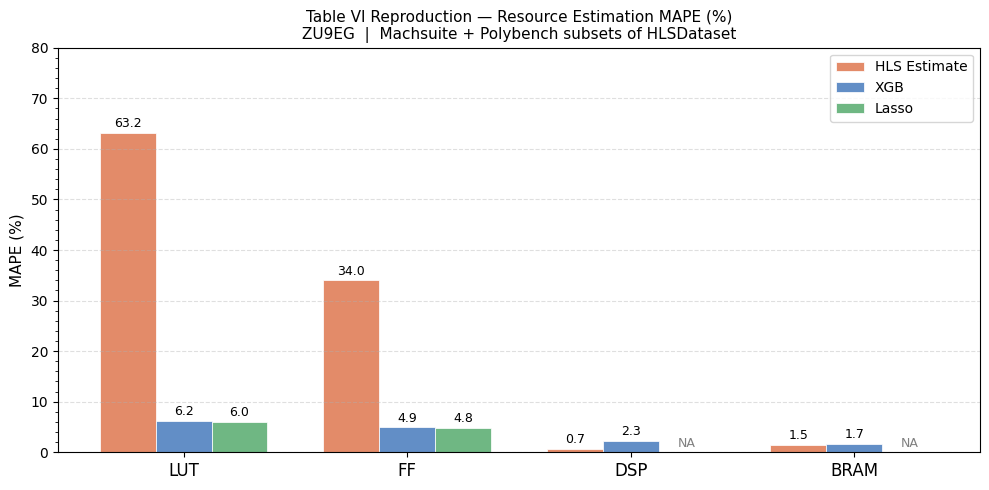

In [11]:
def to_num(v):
    try: return float(str(v).replace('%',''))
    except: return None

resources  = ['LUT','FF','DSP','BRAM']
models_plt = ['HLS Estimate','XGB','Lasso']
colors     = ['#E07B54','#4C7EBF','#5BAD72']
x = np.arange(len(resources))
w = 0.25

fig, ax = plt.subplots(figsize=(10, 5))

for i, (model, color) in enumerate(zip(models_plt, colors)):
    vals = [to_num(table_vi.loc[model, r]) for r in resources]
    bars = ax.bar(
        x + (i-1)*w,
        [v if v is not None else 0 for v in vals],
        width=w, label=model, color=color, alpha=0.88,
        edgecolor='white', linewidth=0.6
    )
    for bar, v in zip(bars, vals):
        txt = f'{v:.1f}' if v is not None else 'NA'
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 0.5,
                txt, ha='center', va='bottom', fontsize=9,
                color='grey' if txt == 'NA' else 'black')

ax.set_xticks(x)
ax.set_xticklabels(resources, fontsize=12)
ax.set_ylabel('MAPE (%)', fontsize=11)
ax.set_title(
    'Table VI Reproduction — Resource Estimation MAPE (%)\n'
    'ZU9EG  |  Machsuite + Polybench subsets of HLSDataset',
    fontsize=11
)
ax.legend(fontsize=10)
ax.grid(axis='y', linestyle='--', alpha=0.4)
ax.set_ylim(0, max(80, ax.get_ylim()[1]*1.15))
ax.yaxis.set_minor_locator(mticker.AutoMinorLocator())
plt.tight_layout()
plt.show()

---
## Cell 12 — Figure: Predicted vs. Actual scatter (all models × all resources)

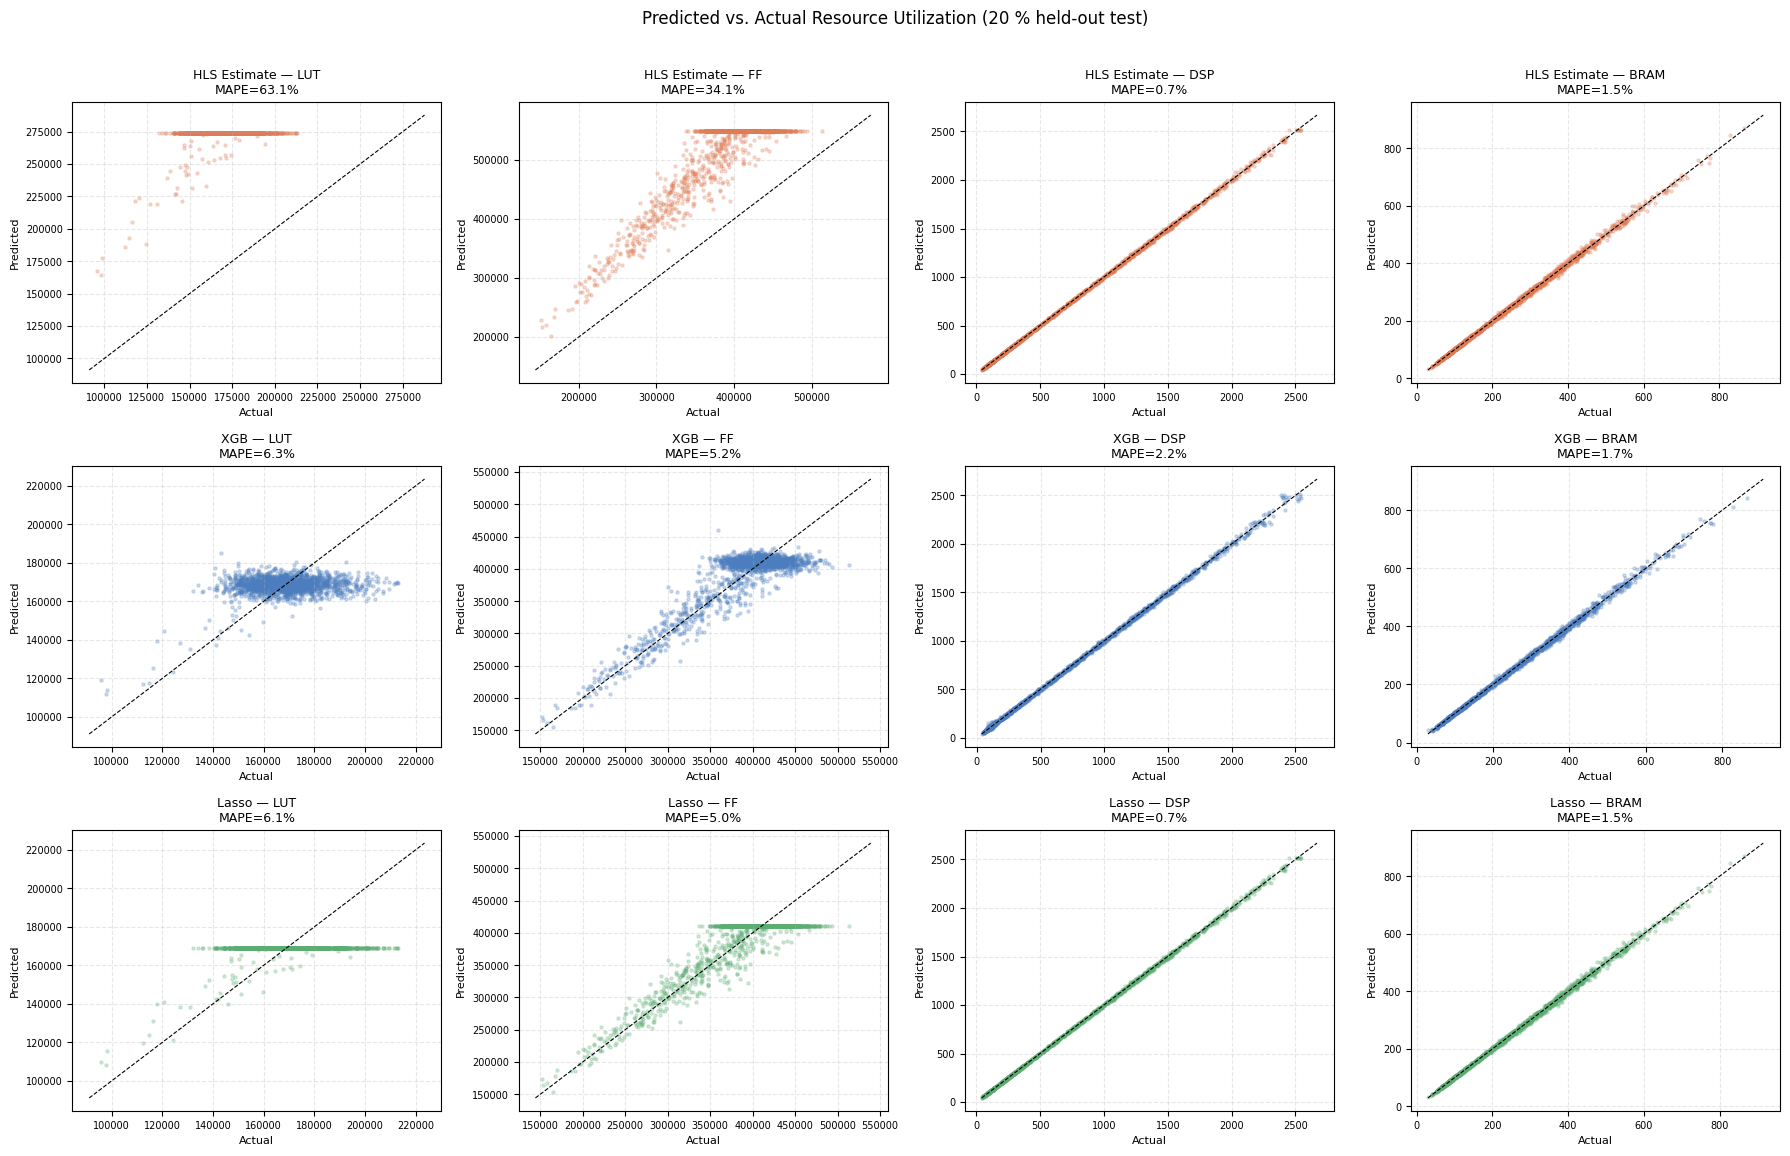

In [12]:
# Collect HLS baseline predictions for the test set
hls_test_preds = {
    res: (df[impl_col].iloc[te_idx].values,
          X.iloc[te_idx][HLS_BASELINE[res]].values)
    for res, impl_col in TARGETS.items()
}

all_preds = {'HLS Estimate': hls_test_preds,
             'XGB':          xgb_test_preds,
             'Lasso':        lasso_test_preds}

plot_colors = {'HLS Estimate':'#E07B54', 'XGB':'#4C7EBF', 'Lasso':'#5BAD72'}
res_list    = list(TARGETS.keys())
mdl_list    = list(all_preds.keys())

fig, axes = plt.subplots(len(mdl_list), len(res_list),
                          figsize=(4.5*len(res_list), 3.8*len(mdl_list)))

for m_i, model in enumerate(mdl_list):
    for r_i, res in enumerate(res_list):
        ax = axes[m_i][r_i]
        yt, yp = all_preds[model][res]
        mask = yt > 0
        me   = 100 * np.mean(np.abs((yt[mask]-yp[mask])/yt[mask]))

        ax.scatter(yt, yp, s=5, alpha=0.25,
                   color=plot_colors[model], rasterized=True)
        lo = min(yt.min(), yp.min()) * 0.95
        hi = max(yt.max(), yp.max()) * 1.05
        ax.plot([lo,hi],[lo,hi],'k--',lw=0.8)
        ax.set_title(f'{model} — {res.upper()}\nMAPE={me:.1f}%', fontsize=9)
        ax.set_xlabel('Actual', fontsize=8)
        ax.set_ylabel('Predicted', fontsize=8)
        ax.tick_params(labelsize=7)
        ax.grid(linestyle='--', alpha=0.3)

fig.suptitle('Predicted vs. Actual Resource Utilization (20 % held-out test)',
             fontsize=12, y=1.01)
plt.tight_layout()
plt.show()

---
## Cell 13 — Figure: Error distribution histograms

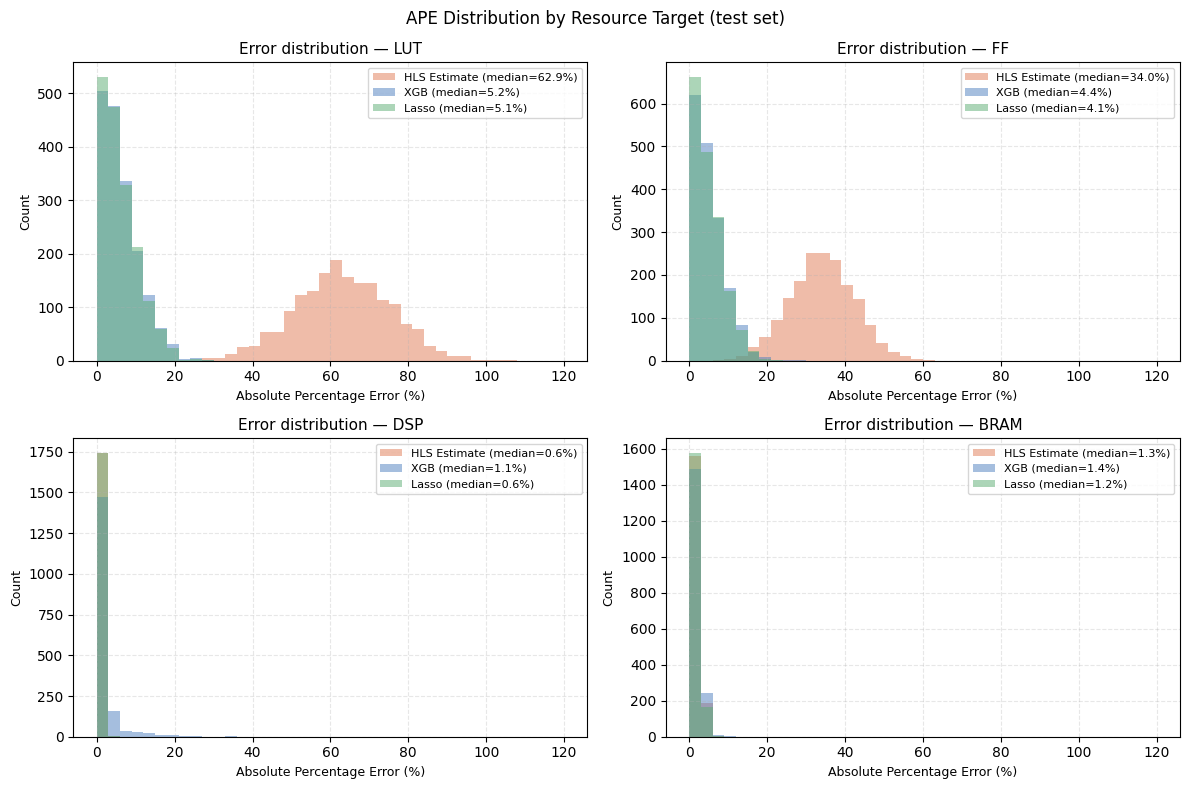

In [13]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()

for ax, res in zip(axes, res_list):
    for model in mdl_list:
        yt, yp = all_preds[model][res]
        mask = yt > 0
        ape  = 100 * np.abs((yt[mask]-yp[mask])/yt[mask])
        ax.hist(ape, bins=40, range=(0,120), alpha=0.5,
                label=f"{model} (median={np.median(ape):.1f}%)",
                color=plot_colors[model])
    ax.set_title(f'Error distribution — {res.upper()}', fontsize=11)
    ax.set_xlabel('Absolute Percentage Error (%)', fontsize=9)
    ax.set_ylabel('Count', fontsize=9)
    ax.legend(fontsize=8)
    ax.grid(linestyle='--', alpha=0.3)

fig.suptitle('APE Distribution by Resource Target (test set)', fontsize=12)
plt.tight_layout()
plt.show()

---
## Cell 14 — Figure: XGB feature importance

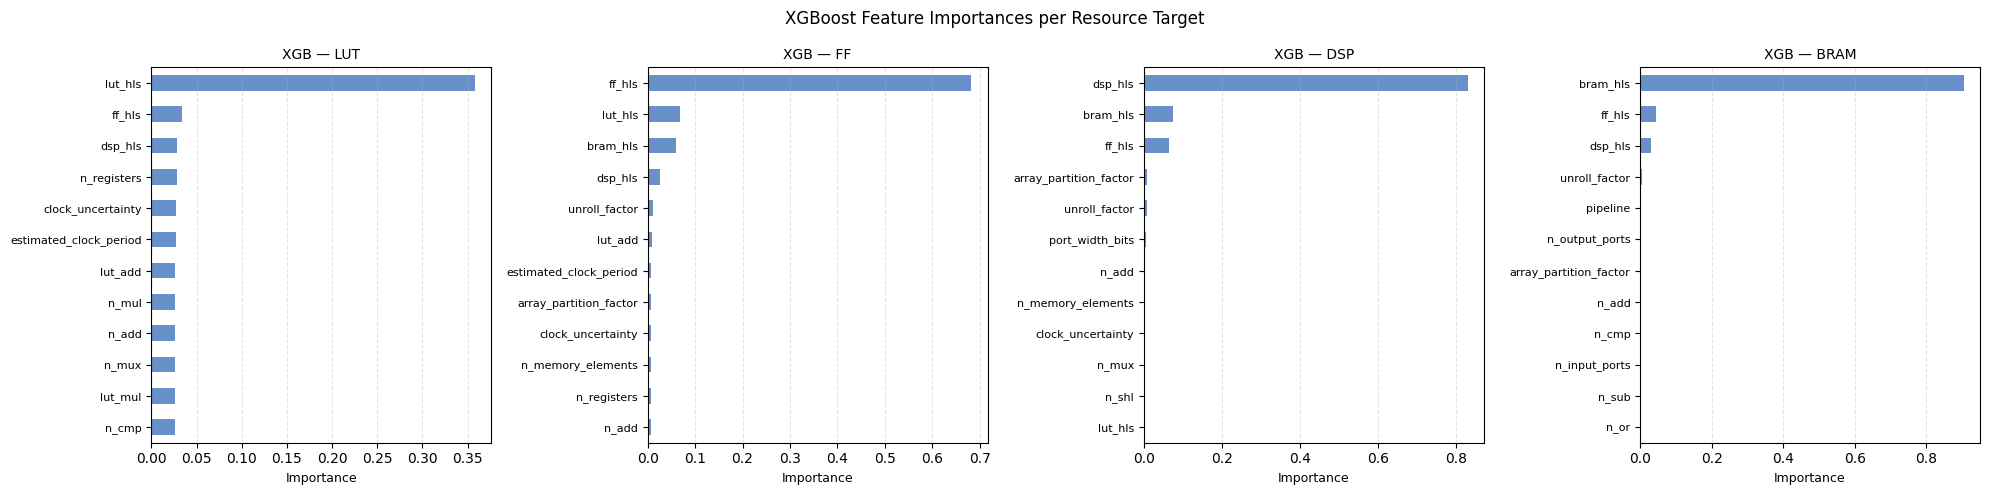

In [14]:
fig, axes = plt.subplots(1, 4, figsize=(20, 5))

for ax, res in zip(axes, res_list):
    imp = pd.Series(xgb_models[res].feature_importances_,
                    index=feature_cols).nlargest(12)
    imp[::-1].plot.barh(ax=ax, color='#4C7EBF', alpha=0.85)
    ax.set_title(f'XGB — {res.upper()}', fontsize=10)
    ax.set_xlabel('Importance', fontsize=9)
    ax.tick_params(axis='y', labelsize=8)
    ax.grid(axis='x', linestyle='--', alpha=0.35)

fig.suptitle('XGBoost Feature Importances per Resource Target', fontsize=12)
plt.tight_layout()
plt.show()

---
## Cell 15 — Figure: Per-benchmark MAPE heatmap (XGB)

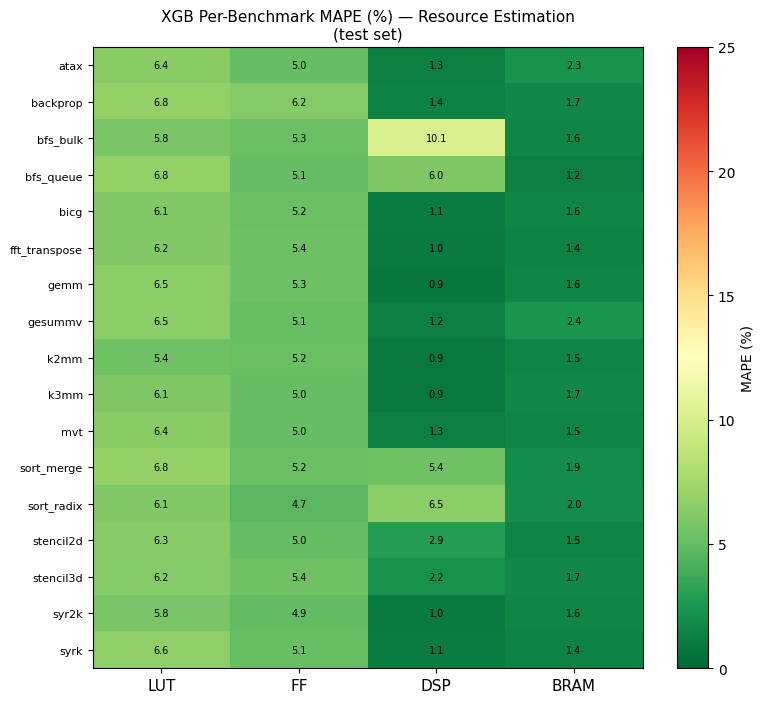

In [15]:
bench_series = df['benchmark'].iloc[te_idx].reset_index(drop=True)
benches      = sorted(bench_series.unique())
mat          = np.full((len(benches), len(res_list)), np.nan)

for r_i, res in enumerate(res_list):
    yt, yp = xgb_test_preds[res]
    for b_i, bench in enumerate(benches):
        mask  = (bench_series == bench).values
        valid = yt[mask] > 0
        if valid.sum() > 0:
            mat[b_i, r_i] = 100 * np.mean(
                np.abs((yt[mask][valid] - yp[mask][valid]) / yt[mask][valid])
            )

fig, ax = plt.subplots(figsize=(8, max(5, len(benches)*0.42)))
im = ax.imshow(mat, aspect='auto', cmap='RdYlGn_r', vmin=0, vmax=25)
plt.colorbar(im, ax=ax, label='MAPE (%)')

ax.set_xticks(range(len(res_list)))
ax.set_xticklabels([r.upper() for r in res_list], fontsize=11)
ax.set_yticks(range(len(benches)))
ax.set_yticklabels(benches, fontsize=8)
ax.set_title('XGB Per-Benchmark MAPE (%) — Resource Estimation\n(test set)', fontsize=11)

for ri in range(len(res_list)):
    for bi in range(len(benches)):
        v = mat[bi, ri]
        if not np.isnan(v):
            ax.text(ri, bi, f'{v:.1f}', ha='center', va='center',
                    fontsize=7, color='black' if v < 18 else 'white')

plt.tight_layout()
plt.show()

---
## Cell 16 — Per-benchmark breakdown table (XGB)

In [16]:
bench_rows = []
for bench in benches:
    mask = (bench_series == bench).values
    row  = {'benchmark': bench, 'n_test_samples': int(mask.sum())}
    for res in res_list:
        yt, yp = xgb_test_preds[res]
        valid  = yt[mask] > 0
        row[f'xgb_{res}_mape'] = (
            round(100*np.mean(np.abs((yt[mask][valid]-yp[mask][valid])/yt[mask][valid])), 1)
            if valid.sum() > 0 else np.nan
        )
    bench_rows.append(row)

bench_df = pd.DataFrame(bench_rows).set_index('benchmark')
print('XGB MAPE (%) by benchmark — test set')
print(bench_df.to_string())

XGB MAPE (%) by benchmark — test set
               n_test_samples  xgb_lut_mape  xgb_ff_mape  xgb_dsp_mape  xgb_bram_mape
benchmark                                                                            
atax                      116           6.4          5.0           1.3            2.3
backprop                   56           6.8          6.2           1.4            1.7
bfs_bulk                   72           5.8          5.3          10.1            1.6
bfs_queue                  71           6.8          5.1           6.0            1.2
bicg                      116           6.1          5.2           1.1            1.6
fft_transpose              68           6.2          5.4           1.0            1.4
gemm                      171           6.5          5.3           0.9            1.6
gesummv                   121           6.5          5.1           1.2            2.4
k2mm                      137           5.4          5.2           0.9            1.5
k3mm             

---
## Cell 17 — (Optional) Save all results to CSV

In [17]:
from pathlib import Path
Path('results').mkdir(exist_ok=True)

table_vi.to_csv('results/table_vi_reproduction.csv')
bench_df.to_csv('results/per_benchmark_errors.csv')

# Feature importance
fi_rows = []
for res in res_list:
    for feat, imp in zip(feature_cols, xgb_models[res].feature_importances_):
        fi_rows.append({'resource': res, 'feature': feat, 'importance': round(float(imp),5)})
fi_df = pd.DataFrame(fi_rows).sort_values(['resource','importance'], ascending=[True,False])
fi_df.to_csv('results/feature_importance.csv', index=False)

print('Saved:')
print('  results/table_vi_reproduction.csv')
print('  results/per_benchmark_errors.csv')
print('  results/feature_importance.csv')

Saved:
  results/table_vi_reproduction.csv
  results/per_benchmark_errors.csv
  results/feature_importance.csv


---
## Notes: switching to the REAL HLSDataset

```python
# 1. Clone the repo (run in a Colab cell)
!git clone https://github.com/UT-LCA/ML4Accel-Dataset.git

# 2. Concatenate per-benchmark CSVs
import glob
hls_df  = pd.concat([pd.read_csv(f) for f in
              glob.glob('ML4Accel-Dataset/fpga_ml_dataset/**/post_hls_info.csv',
                        recursive=True)], ignore_index=True)
impl_df = pd.concat([pd.read_csv(f) for f in
              glob.glob('ML4Accel-Dataset/fpga_ml_dataset/**/post_impl_info.csv',
                        recursive=True)], ignore_index=True)

# 3. Run Cell 4 onward — update feature_cols if column names differ
```

Column names may differ slightly in the real CSVs — print `hls_df.columns.tolist()`
and update `ALL_FEATURES` / `TARGETS` / `HLS_BASELINE` accordingly.